## Imports

In [2]:
# imports
import warnings
import yfinance as yf
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf ,plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.tsa.x13 import x13_arima_analysis
from tabulate import tabulate

c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Configuring General Settings 

In [3]:
# general settings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## Loading Data

In [4]:
# import data
ticker = "BA"
df_boeing = yf.download(ticker, start="2020-01-01", end="2023-10-01")

[*********************100%%**********************]  1 of 1 completed


## EDA

In [5]:
print("Data Shape:", df_boeing.shape)
df_boeing.head()

Data Shape: (943, 6)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,328.549988,333.350006,327.700012,333.320007,331.348572,4544400
2020-01-03,330.630005,334.890015,330.299988,332.760010,330.791901,3875900
2020-01-06,329.299988,334.859985,327.880005,333.739990,331.766083,5355000
2020-01-07,334.260010,344.190002,330.709991,337.279999,335.285156,9898600
2020-01-08,332.399994,334.029999,329.600006,331.369995,329.410095,8239200


<Axes: xlabel='Date', ylabel='Adj Close'>

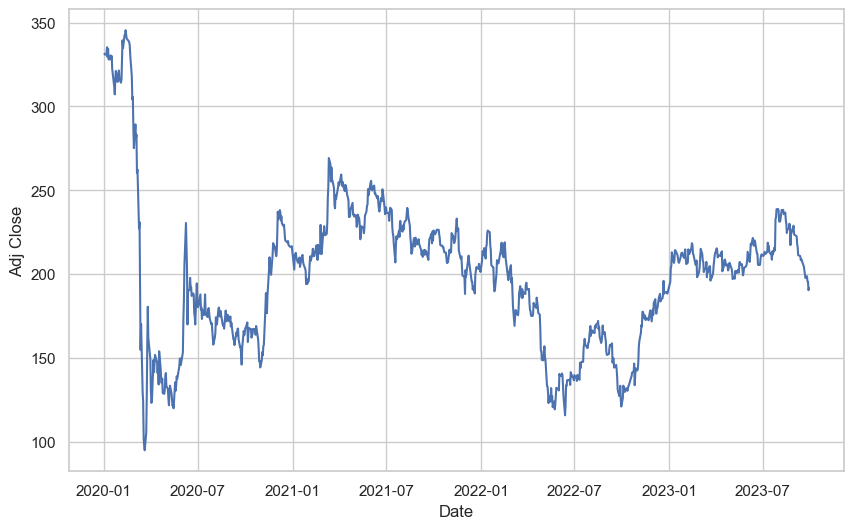

In [6]:
plt.figure(figsize=(10,6))
df_adj_close = df_boeing["Adj Close"].reset_index(drop=True)
sns.lineplot(x=df_boeing.index, y=df_adj_close)

The daily Boeing stock price process is not stationary and it dosen't represent a well defined trend and seasonality

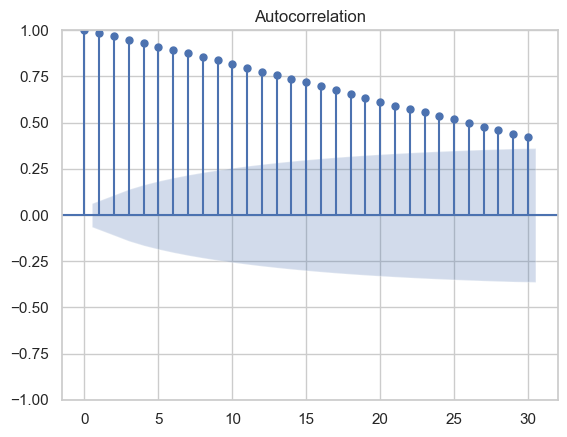

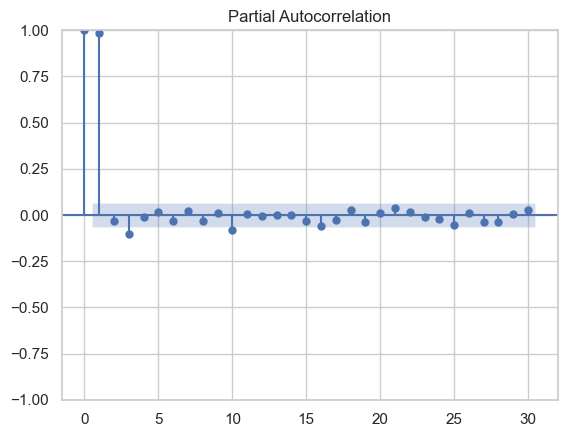

In [7]:
plot_acf(df_adj_close)
plot_pacf(df_adj_close)
plt.show()

We see that the autocorrelation function decrease progressively over lags which not allow us the fix the MA order. On the other hand the partial autocorrelation decrease dramatically from 1 lag so we can fix the AR order to 1.

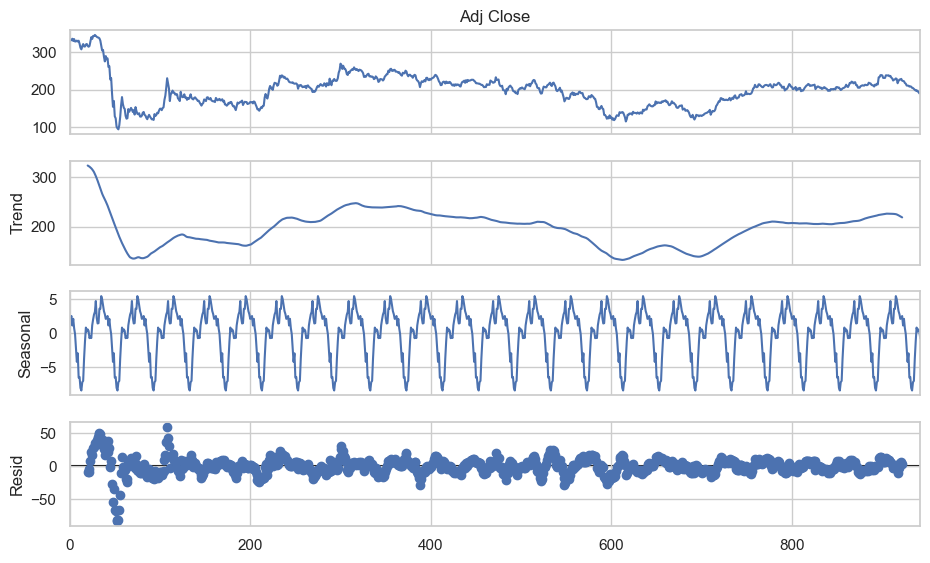

In [17]:
result = seasonal_decompose(df_adj_close, model='additive', period=40)
fig = result.plot()
fig.set_figwidth(10)
fig.set_figheight(6)
fig.show()

In [40]:
result = STL(df_adj_close, seasonal=5, trend=6, period=4).fit()
result.plot()
plt.show()

ValueError: trend must be an odd positive integer >= 3 where trend > period

100    -8.723342
101    -9.203516
102   -12.924807
103    -8.781038
104    -8.023641
         ...    
195     0.880511
196     1.219152
197    -3.558237
198    -2.122897
199    -0.981331
Name: resid, Length: 100, dtype: float64

<Axes: xlabel='Date', ylabel='Adj Close'>

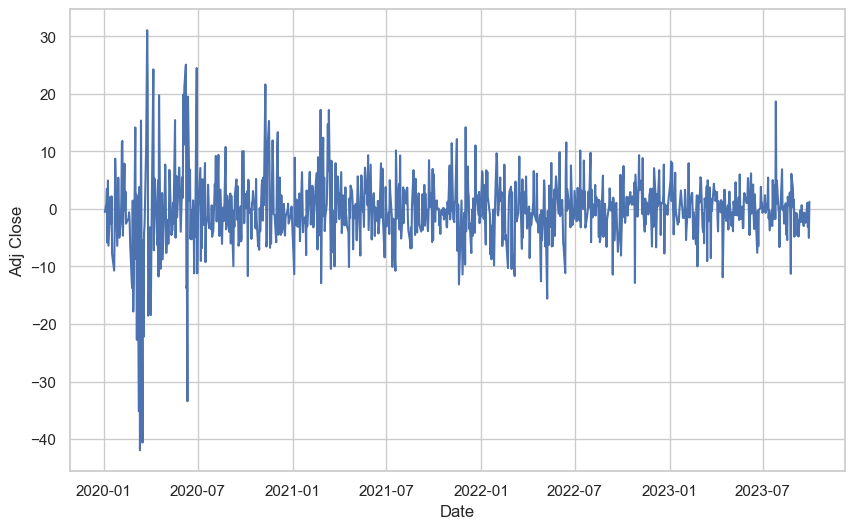

In [10]:
plt.figure(figsize=(10,6))
sns.lineplot(x=df_boeing.index[1:], y=df_adj_close.diff(1).dropna())

The process trend was removed after applying an integration to order 1, so we can fix the integration order to 1.

## Modeling & Model Evaluation

In [15]:
# define training and testing data
df_train = df_adj_close[:-300]
df_test = df_adj_close[-300:]

In [16]:
# try different MA orders
for i in range(5):
    arima_model = ARIMA(df_train, order=(1,1,i))
    arima_model_fit = arima_model.fit()
    print(f"* MA order = {i}\n{arima_model_fit.summary()}")

* MA order = 0
                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                  643
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -2170.541
Date:                Sat, 13 Jan 2024   AIC                           4345.081
Time:                        17:39:34   BIC                           4354.010
Sample:                             0   HQIC                          4348.547
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0500      0.021      2.399      0.016       0.009       0.091
sigma2        50.5988      1.375     36.790      0.000      47.903      53.294
Ljung-Box (L1) (Q):                  

The overall best MA order is 1

In [17]:
# create and fit the ARIMA model
arima_model = ARIMA(df_train, order=(1,1,1))
arima_model_fit = arima_model.fit()

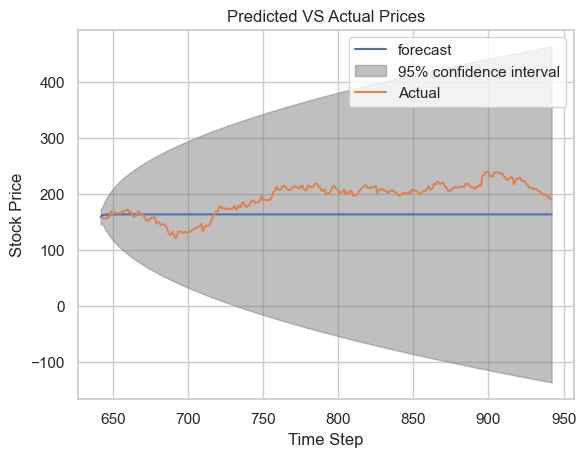

In [18]:
from statsmodels.graphics.tsaplots import plot_predict
arima_model = ARIMA(df_train, order=(1,1,1))
arima_model_fit = arima_model.fit()
plot_predict(arima_model_fit, start=642, end=942)
plt.plot(df_test, label="Actual")
plt.xlabel("Time Step")
plt.ylabel("Stock Price")
plt.title("Predicted VS Actual Prices")
plt.legend()
plt.show()

In [19]:
# display metrics for regression model
def regression_metrics(model, x_train, x_test) :
    start_train = x_train.index[0]
    end_train = x_train.index[-1]
    start_test = x_test.index[0]
    end_test = x_test.index[-1]
    y_train_pred = model.predict(start=start_train, end=end_train)
    y_test_pred = model.predict(start=start_test, end=end_test)
    tab = tabulate([["Metric","Training Set","Test Set"],
                  ["r2",r2_score(x_train,y_train_pred),r2_score(x_test,y_test_pred)],
                  ["MSE",mean_squared_error(x_train,y_train_pred),mean_squared_error(x_test,y_test_pred)],
                  ["MAE",mean_absolute_error(x_train,y_train_pred),mean_absolute_error(x_test,y_test_pred)],
                  ["RMSE",mean_squared_error(x_train,y_train_pred,squared=False),mean_squared_error(x_test,y_test_pred,squared=False)]],
                headers='firstrow',numalign="left")
    return tab
print(regression_metrics(arima_model_fit, df_train, df_test))

Metric    Training Set    Test Set
--------  --------------  ----------
r2        0.905843        -0.999115
MSE       220.838         1642.12
MAE       5.3497          35.8876
RMSE      14.8606         40.523


In [20]:
df_train.columns = ["ds","y"]
df_test.columns = ["ds","y"]

In [93]:
import statsmodels.api as sm
import os
x12_path = os.path.join("path", "to", "x13as", "winx13_V2.4")
# Load your data
dta = sm.datasets.co2.load_pandas().data

# Interpolate missing values
dta.co2.interpolate(inplace=True)

# Resample data to monthly frequency
dta = dta.resample('M').sum()

# Select ARIMA order


# Perform X-13ARIMA analysis
results = sm.tsa.x13_arima_analysis(df.reset_index(drop=True))

# Plot the results
fig = results.plot()
fig.set_size_inches(12, 5)
fig.tight_layout()

TypeError: cannot infer freq from a non-convertible index of dtype int64

In [84]:
df[""] = dta.resample('M').sum()
df = df_boeing["Adj Close"]
df.interpolate(inplace=True)
df.index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2023-09-18', '2023-09-19', '2023-09-20', '2023-09-21',
               '2023-09-22', '2023-09-25', '2023-09-26', '2023-09-27',
               '2023-09-28', '2023-09-29'],
              dtype='datetime64[ns]', length=943, freq=None)

In [59]:
df = df_boeing["Adj Close"]
start_date = df.index.min()
end_date = df.index.max()
full_index = pd.date_range(start=start_date, end=end_date, freq='D')
df = df.reindex(full_index)
df.interpolate(inplace=True)

In [58]:
df

0      331.348572
1      330.791901
2      331.766083
3      335.285156
4      329.410095
          ...    
938    198.779999
939    195.639999
940    195.460007
941    190.429993
942    191.679993
Name: Adj Close, Length: 943, dtype: float64